
# Segmentación de Clientes con K-Means

En este trabajo se aplica el algoritmo de clustering **K-Means** con el objetivo de identificar segmentos latentes de clientes a partir de su comportamiento de compra y uso del sitio web.

A diferencia de los métodos supervisados, K-Means permite agrupar clientes sin etiquetas previas, descubriendo patrones ocultos en los datos.



## Objetivo

Identificar grupos de clientes con características similares para:

- Detectar patrones de consumo
- Mejorar estrategias comerciales
- Optimizar campañas de marketing


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score




## Dataset

El dataset contiene las siguientes variables:

- **purchase_freq_month**: Frecuencia de compras por mes  
- **avg_basket_usd**: Ticket promedio por compra en USD  
- **time_on_site_min**: Tiempo de permanencia en el sitio (minutos)  
- **discount_sensitivity**: Sensibilidad a descuentos (0 a 1)  
- **returns_rate**: Tasa de devoluciones (0 a 0.8 aprox.)  

Se incluyen variables adicionales de ruido (**noise_gauss** y **noise_uniform**), que no serán utilizadas en el análisis ya que no aportan valor al modelo.


In [22]:
sns.set()

df = pd.read_csv("dataset_segmentacion_clientes.csv",sep=",", engine="python")

# Vista inicial
df.head()

# Info general
df.info()

# Estadísticas
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_freq_month   700 non-null    float64
 1   avg_basket_usd        700 non-null    float64
 2   time_on_site_min      700 non-null    float64
 3   discount_sensitivity  700 non-null    float64
 4   returns_rate          700 non-null    float64
 5   noise_gauss           700 non-null    float64
 6   noise_uniform         700 non-null    float64
dtypes: float64(7)
memory usage: 38.4 KB


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,5.875724,248.173491,16.784799,0.425083,0.337194,0.023814,-0.010523
std,4.471079,154.904372,12.914111,0.431467,0.356623,1.009325,1.679810
min,0.100000,86.994100,3.163206,0.000000,0.000000,-3.566175,-2.993585
25%,2.278418,90.766945,6.603950,0.000000,0.000000,-0.654168,-1.424864
50%,4.134580,180.223799,9.974407,0.296475,0.165559,0.076845,0.013148
75%,11.214919,449.719033,34.341360,1.000000,0.800000,0.728304,1.407124
max,14.603388,452.973583,38.348156,1.000000,0.800000,2.863317,2.995020


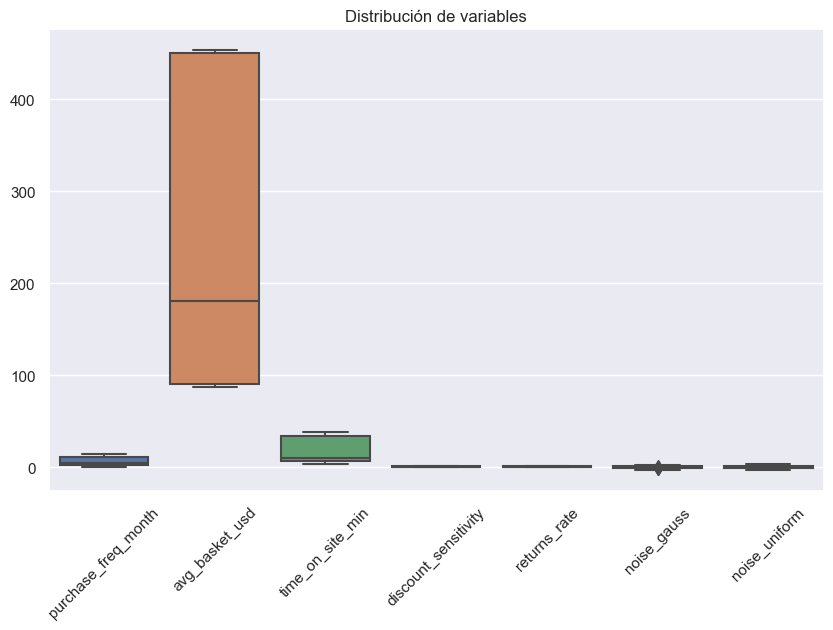

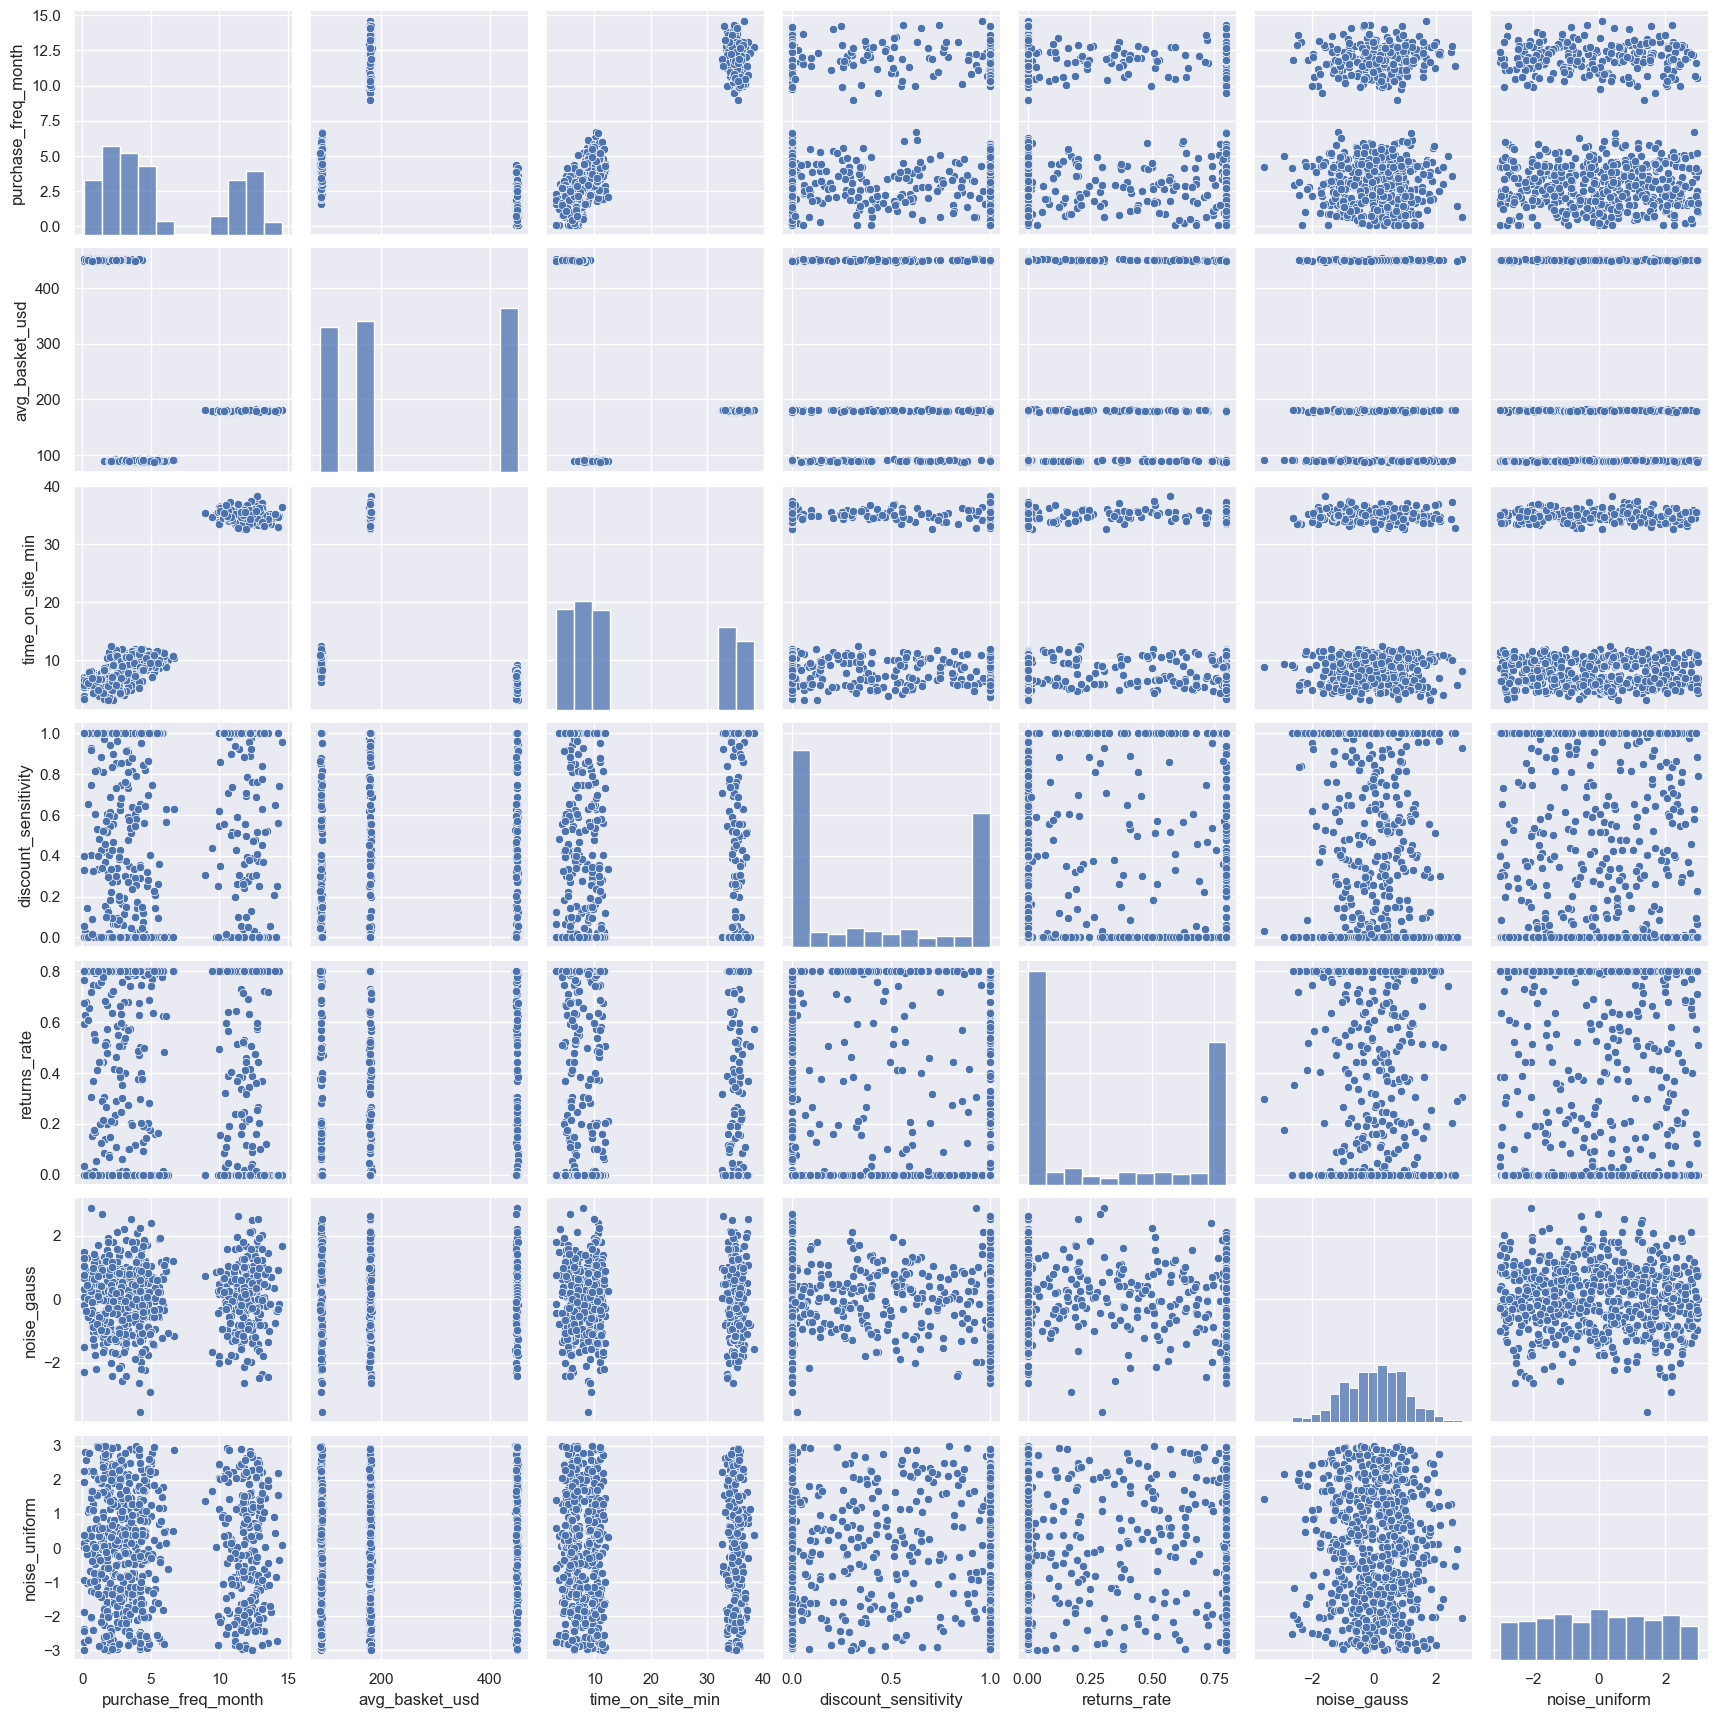

In [15]:

# ==========================================
# 3. EXPLORACIÓN RÁPIDA
# ==========================================
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Distribución de variables")
plt.show()

sns.pairplot(df)
plt.show()



##  Escalado de variables

Se utiliza **StandardScaler** para normalizar los datos, asegurando que todas las variables contribuyan de manera equitativa al modelo.


In [23]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Convertimos a DataFrame para mejor visualización
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
X_scaled_df.head()


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,1.181048,-0.432012,1.300224,1.333423,1.298671,-1.814779,-1.493130
1,1.382696,-0.449219,1.444979,0.834706,-0.946196,0.616014,1.266514
2,-0.822026,1.305039,-0.755841,1.097540,-0.946196,-0.070613,-0.425143
3,-0.367604,-1.028253,-0.461093,-0.985910,1.298671,0.870397,-1.765451
4,-0.930849,1.302382,-0.738500,-0.985910,-0.936996,0.359109,1.450632



## Método del Codo

Se evalúan distintos valores de *k* (cantidad de clusters) entre 2 y 6.

El método del codo permite identificar el punto donde agregar más clusters no mejora significativamente la inercia del modelo.


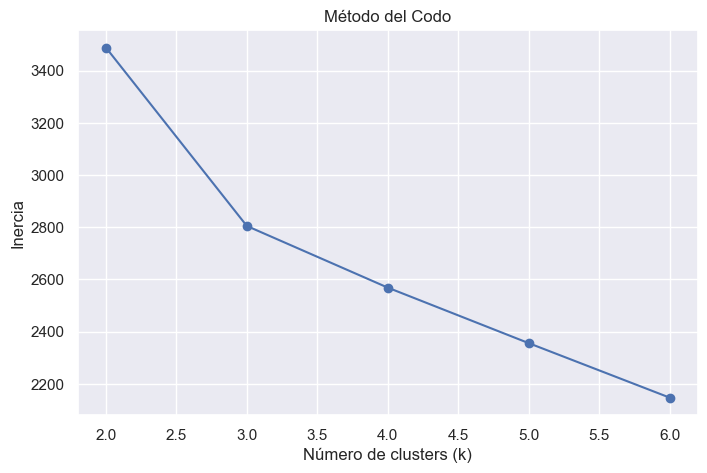

In [24]:
inertia = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Gráfico
plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()



## Validación con Silhouette Score

El coeficiente de silhouette mide qué tan bien se agrupa cada punto dentro de su cluster.

Valores cercanos a 1 indican una buena separación entre clusters.


In [25]:
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k} → silhouette: {score:.3f}")


k=2 → silhouette: 0.288
k=3 → silhouette: 0.279
k=4 → silhouette: 0.252
k=5 → silhouette: 0.227
k=6 → silhouette: 0.242



## Modelo de Clustering

Se selecciona el valor óptimo de **k = X** (ajustar según tu gráfico).

Luego se aplica K-Means para asignar cada cliente a un cluster.


In [26]:
k_optimo = 3

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

df.head()


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform,cluster
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905,2
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460,2
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173,1
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026,0
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522,1



## Análisis de Clusters

Se analizan los centroides y promedios de cada cluster para interpretar los perfiles de clientes.


In [27]:
centroides = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]  # excluye cluster
)

centroides


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,4.091883,89.957567,10.003793,0.379465,0.298761,-0.032045,-0.132205
1,1.846908,450.123746,5.973739,0.358088,0.375371,0.052026,0.123291
2,11.961153,179.999315,35.022131,0.541539,0.332461,0.046581,-0.039583



## Análisis de Clusters

Se analizan los centroides y promedios de cada cluster para interpretar los perfiles de clientes.


In [28]:

# Promedio por cluster
cluster_summary = df.groupby("cluster").mean()
cluster_summary


,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
cluster,,,,,,,
0,4.091883,89.957567,10.003793,0.379465,0.298761,-0.032045,-0.132205
1,1.846908,450.123746,5.973739,0.358088,0.375371,0.052026,0.123291
2,11.961153,179.999315,35.022131,0.541539,0.332461,0.046581,-0.039583




## Perfiles de Clientes

A partir del modelo K-Means con **k = 3**, se identificaron tres segmentos de clientes con comportamientos claramente diferenciados.


### Cluster 0 — Clientes regulares sensibles al precio

- Frecuencia de compra: ~4 compras/mes  
- Ticket promedio: ~90 USD  
- Tiempo en sitio: ~10 minutos  
- Sensibilidad a descuentos: media (~0.38)  
- Tasa de devoluciones: media (~0.29)  

Perfil:
Clientes con comportamiento equilibrado. Compran con cierta regularidad, con tickets bajos a medios, y muestran sensibilidad moderada a descuentos.

Estrategia:
- Promociones ocasionales  
- Programas de fidelización  
- Ofertas personalizadas  


### Cluster 1 — Clientes premium esporádicos

- Frecuencia de compra: ~1.8 compras/mes  
- Ticket promedio: ~450 USD  
- Tiempo en sitio: ~6 minutos  
- Sensibilidad a descuentos: media (~0.36)  
- Tasa de devoluciones: alta (~0.37)  

Perfil:
Clientes que compran poco, pero realizan compras de alto valor. No pasan mucho tiempo en el sitio, lo que sugiere decisiones rápidas.

Estrategia:
- Upselling y productos premium  
- Experiencia de compra rápida (UX optimizada)  
- Atención personalizada  

---

### Cluster 2 — Clientes intensivos y exploradores

- Frecuencia de compra: ~12 compras/mes  
- Ticket promedio: ~180 USD  
- Tiempo en sitio: ~35 minutos  
- Sensibilidad a descuentos: alta (~0.54)  
- Tasa de devoluciones: media (~0.33)  

Perfil:
Clientes altamente activos, que navegan mucho en el sitio y compran frecuentemente. Además, presentan mayor sensibilidad a descuentos.

 Estrategia:
- Descuentos y promociones constantes  
- Recomendaciones personalizadas  
- Programas de recompensas  



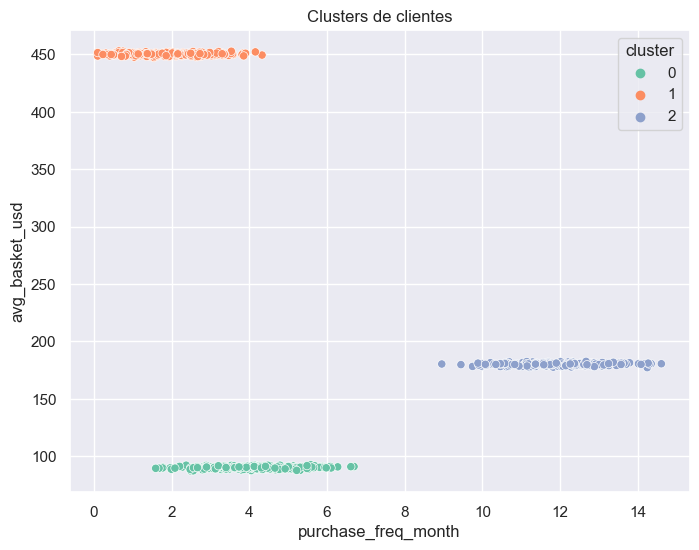

In [29]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="purchase_freq_month",
    y="avg_basket_usd",
    hue="cluster",
    palette="Set2"
)
plt.title("Clusters de clientes")
plt.show()



## Conclusión

El modelo K-Means permitió identificar tres segmentos de clientes claramente diferenciados, lo que confirma la existencia de patrones de comportamiento distintos.

El valor **k = 3** resultó adecuado según el método del codo y el análisis de los clusters.

Se identificaron los siguientes perfiles:

- Clientes regulares sensibles al precio (Cluster 0)
- Clientes premium esporádicos (Cluster 1)
- Clientes intensivos y exploradores (Cluster 2)

Estos hallazgos permiten diseñar estrategias específicas para cada segmento, optimizando acciones de marketing, fidelización y experiencia del usuario.
